In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [57]:
data = pd.read_excel("railway Clean 1.4.xlsx")

data.head()


FileNotFoundError: [Errno 2] No such file or directory: 'railway Clean 1.4.xlsx'

In [4]:
data["Time Delay(Minutes)"] = pd.to_numeric(
    data["Time Delay(Minutes)"],
    errors="coerce"
)

data = data.dropna(
    subset=["Time Delay(Minutes)"]
)

In [5]:
features = [
    "Departure Station",
    "Arrival Destination",
    "Journey Day",
    "Departure Time",
    "Reason for Delay"
]

X = data[features].copy()

y = data["Time Delay(Minutes)"]

In [6]:
X = X.fillna("Unknown")

In [7]:
encoders = {}

for col in X.columns:
    encoder = LabelEncoder()
    X[col] = encoder.fit_transform(X[col])
    encoders[col] = encoder

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [10]:
model.fit(
    X_train,
    y_train
)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [11]:
y_pred = model.predict(X_test)

In [12]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

r2 = r2_score(
    y_test,
    y_pred
)


print("MAE:", mae)
print("R2 Score:", r2)

MAE: 0.884228580425839
R2 Score: 0.8117587665380531


In [13]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})


importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
4,Reason for Delay,0.863757
2,Journey Day,0.044559
3,Departure Time,0.038831
1,Arrival Destination,0.027934
0,Departure Station,0.024920


In [14]:
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [15]:
new_trip = pd.DataFrame({
    "Departure Station": ["London Euston"],
    "Arrival Destination": ["Manchester Piccadilly"],
    "Journey Day": ["Monday"],
    "Departure Time": [pd.to_datetime("08:30").time()],
    "Reason for Delay": ["Technical Issue"]
})

new_trip

,Departure Station,Arrival Destination,Journey Day,Departure Time,Reason for Delay
0,London Euston,Manchester Piccadilly,Monday,08:30:00,Technical Issue


In [16]:
for col in new_trip.columns:
    new_trip[col] = encoders[col].transform(new_trip[col])

In [17]:
prediction = model.predict(new_trip)

print("Expected Delay:", prediction[0], "minutes")

Expected Delay: 24.374542032915482 minutes


In [18]:
y_pred = model.predict(X_test)

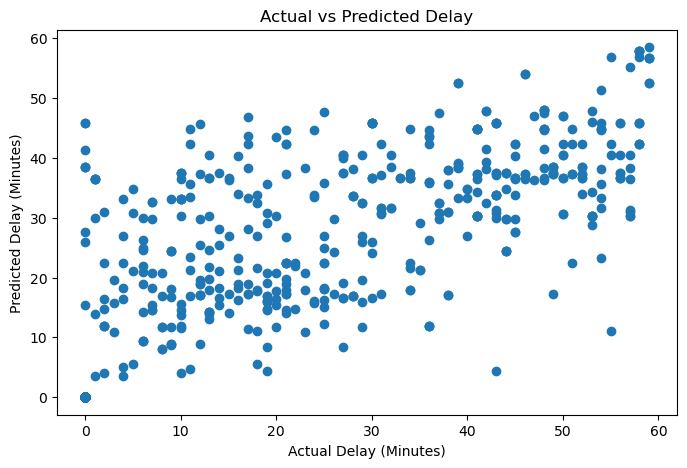

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Delay (Minutes)")
plt.ylabel("Predicted Delay (Minutes)")

plt.title("Actual vs Predicted Delay")

plt.show()

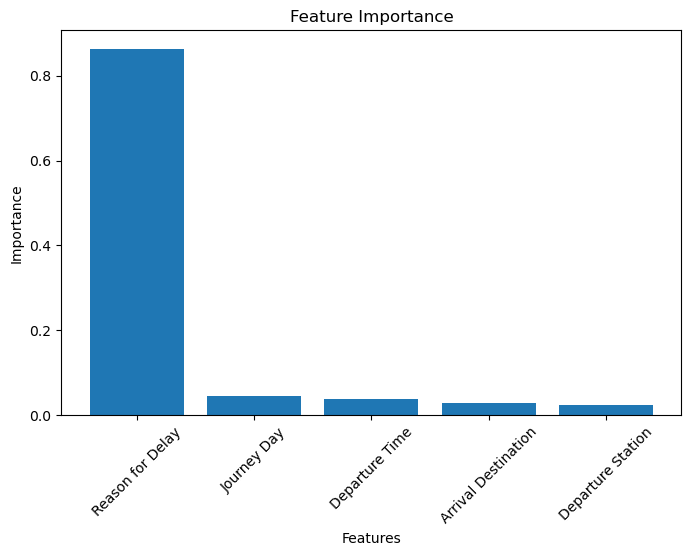

In [23]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})


importance = importance.sort_values(
    by="Importance",
    ascending=False
)


plt.figure(figsize=(8,5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.xticks(rotation=45)

plt.xlabel("Features")
plt.ylabel("Importance")

plt.title("Feature Importance")

plt.show()

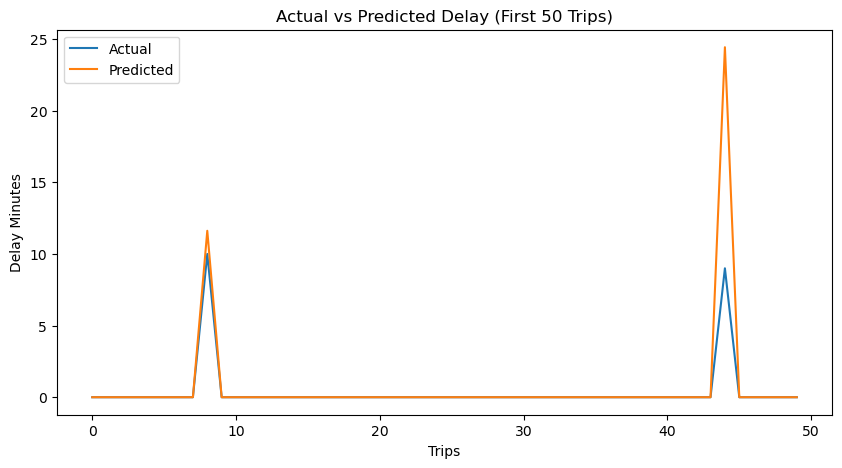

In [24]:
plt.figure(figsize=(10,5))

plt.plot(
    y_test.values[:50],
    label="Actual"
)

plt.plot(
    y_pred[:50],
    label="Predicted"
)

plt.xlabel("Trips")
plt.ylabel("Delay Minutes")

plt.title("Actual vs Predicted Delay (First 50 Trips)")

plt.legend()

plt.show()

In [26]:
import pandas as pd

In [27]:
data = pd.read_excel(r"C:\Users\elmnshawy\Downloads\railway Clean 1.4.xlsx")

In [29]:
data['Date of Purchase'] = pd.to_datetime(data['Date of Purchase'])

In [31]:
print(data.columns.tolist())

['Transaction ID', 'Date of Purchase', 'Purchase Day', 'Time of Purchase', 'Purchase Type', 'Payment Method', 'Railcard', 'Ticket Class', 'Ticket Type', ' Price ', 'Departure Station', 'Arrival Destination', 'Date of Journey', 'Journey Day', 'Departure Time', 'Arrival Time', 'Actual Arrival Time', 'Journey Status', 'Time Delay(Minutes)', 'Reason for Delay', 'Refund Request']


In [32]:
data.columns = data.columns.str.strip()

In [33]:
print(data.columns.tolist())

['Transaction ID', 'Date of Purchase', 'Purchase Day', 'Time of Purchase', 'Purchase Type', 'Payment Method', 'Railcard', 'Ticket Class', 'Ticket Type', 'Price', 'Departure Station', 'Arrival Destination', 'Date of Journey', 'Journey Day', 'Departure Time', 'Arrival Time', 'Actual Arrival Time', 'Journey Status', 'Time Delay(Minutes)', 'Reason for Delay', 'Refund Request']


In [34]:
daily_revenue = data.groupby('Date of Purchase')['Price'].sum().reset_index()

daily_revenue.head()

,Date of Purchase,Price
0,2023-12-08,43
1,2023-12-16,23
2,2023-12-19,3
3,2023-12-20,13
4,2023-12-27,76


In [35]:
data.columns = data.columns.str.strip()

In [36]:
daily_revenue = data.groupby('Date of Purchase')['Price'].sum().reset_index()

In [37]:
data.columns = data.columns.str.strip()

In [38]:
data['Date of Purchase'] = pd.to_datetime(data['Date of Purchase'])

In [39]:
daily_revenue = data.groupby('Date of Purchase')['Price'].sum().reset_index()

daily_revenue.head()

,Date of Purchase,Price
0,2023-12-08,43
1,2023-12-16,23
2,2023-12-19,3
3,2023-12-20,13
4,2023-12-27,76


In [40]:
daily_revenue['Day'] = daily_revenue['Date of Purchase'].dt.day
daily_revenue['Month'] = daily_revenue['Date of Purchase'].dt.month
daily_revenue['Year'] = daily_revenue['Date of Purchase'].dt.year
daily_revenue['DayOfWeek'] = daily_revenue['Date of Purchase'].dt.dayofweek

In [41]:
daily_revenue.head()

,Date of Purchase,Price,Day,Month,Year,DayOfWeek
0,2023-12-08,43,8,12,2023,4
1,2023-12-16,23,16,12,2023,5
2,2023-12-19,3,19,12,2023,1
3,2023-12-20,13,20,12,2023,2
4,2023-12-27,76,27,12,2023,2


In [42]:
X = daily_revenue[['Day', 'Month', 'Year', 'DayOfWeek']]
y = daily_revenue['Price']

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [56]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [50]:
from xgboost import XGBRegressor

In [51]:
model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [52]:
y_pred = model.predict(X_test)

In [53]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE =", mean_absolute_error(y_test, y_pred))
print("RMSE =", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 =", r2_score(y_test, y_pred))

MAE = 835.9302368164062
RMSE = 1022.0850013575192
R2 = 0.774951696395874


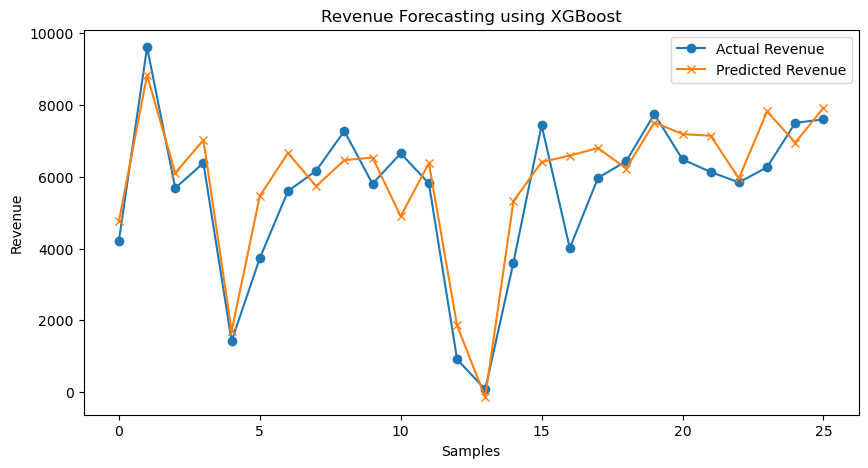

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test.values, marker='o', label='Actual Revenue')
plt.plot(y_pred, marker='x', label='Predicted Revenue')
plt.title("Revenue Forecasting using XGBoost")
plt.xlabel("Samples")
plt.ylabel("Revenue")
plt.legend()
plt.show()

In [55]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance.sort_values(by='Importance', ascending=False)

,Feature,Importance
1,Month,0.707847
0,Day,0.189371
3,DayOfWeek,0.102782
2,Year,0.000000


In [58]:
model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [59]:
new_data = pd.DataFrame({
    'Day': [15],
    'Month': [7],
    'Year': [2024],
    'DayOfWeek': [0]   # 0 = Monday
})

prediction = model.predict(new_data)

print("Predicted Revenue:", prediction[0])

Predicted Revenue: 7244.397


In [60]:
new_data = pd.DataFrame({
    'Day': [5],
    'Month': [2],
    'Year': [2025],
    'DayOfWeek': [2]  
})

prediction = model.predict(new_data)

print("Predicted Revenue:", prediction[0])

Predicted Revenue: 9212.565
